# FineWeb Shard Analysis

This notebook presents a structured exploratory analysis of a FineWeb shard. It covers:

- basic structure and schema
- completeness and exact duplicates
- numeric distributions
- derived text features
- language profile
- source domains and URL patterns
- time distribution
- outlier inspection
- summary audit

The goal is to document the shard clearly and provide a concise evidence-based profile of its contents.

In [1]:
# Run this cell first if the required packages are not yet installed.
import sys
!{sys.executable} -m pip install -q pyarrow pandas matplotlib

In [2]:
import re
from urllib.parse import urlparse

import pandas as pd
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import matplotlib.pyplot as plt

# ===== Configuration =====
FILE_PATH = "../data/fineweb/004_00018.parquet"
HEAD_N = 5
RANDOM_SEED = 42

# Display settings for cleaner tables
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

print("Using file:", FILE_PATH)

Using file: ../data/fineweb/004_00018.parquet


## 1. Basic Structure

This section reports:

- the number of rows and columns
- the schema
- the number of row groups
- a small sample of records

In [3]:
pf = pq.ParquetFile(FILE_PATH)

print("=== Basic Information ===")
print("Row groups:", pf.num_row_groups)
print("Number of rows:", pf.metadata.num_rows)
print("Number of columns:", pf.metadata.num_columns)

print("\n=== Schema ===")
schema = pf.schema_arrow
for field in schema:
    print(f"{field.name:15} -> {field.type}")

dataset = ds.dataset(FILE_PATH, format="parquet")
sample_df = dataset.head(HEAD_N).to_pandas()

print("\n=== Sample Rows ===")
display(sample_df)

print("\n=== Pandas dtypes ===")
display(sample_df.dtypes.to_frame("dtype"))

=== Basic Information ===
Row groups: 173
Number of rows: 172447
Number of columns: 9

=== Schema ===
text            -> string
id              -> string
dump            -> string
url             -> string
date            -> string
file_path       -> string
language        -> string
language_score  -> double
token_count     -> int64

=== Sample Rows ===


,text,id,dump,url,date,file_path,language,language_score,token_count
0,"Welcome to Harrisonburg TownSquare.\nTownSquare brings together all your favorite local shops and makers in one cozy corner of the internet, so you can support your neighbors and find something tr...",<urn:uuid:189514cf-784a-4e9f-9e8e-f350c5a41adf>,CC-MAIN-2025-26,https://www.townsquareapp.co/,2025-06-16T16:22:40Z,s3://commoncrawl/crawl-data/CC-MAIN-2025-26/segments/1749709481416.36/warc/CC-MAIN-20250616145137-20250616175137-00968.warc.gz,en,0.899284,203
1,"The Art of Effective Board Reporting\nSep 5, 2024\nBoard reporting is a cornerstone of corporate governance, serving as the primary channel through which the board of directors gains insight into ...",<urn:uuid:9d2f701d-48f5-418f-a8e2-d5b2d51aad36>,CC-MAIN-2025-26,https://www.traact.com/blog/the-art-of-effective-board-reporting,2025-06-16T16:45:14Z,s3://commoncrawl/crawl-data/CC-MAIN-2025-26/segments/1749709481416.36/warc/CC-MAIN-20250616145137-20250616175137-00968.warc.gz,en,0.942698,2717
2,Belinda's journey and transformation is a real triumph over so much personal stress and pressure. I have a huge amount of respect and admiration for Belinda who has kept going despite all the setb...,<urn:uuid:ccb16b4e-f301-480c-9231-33f6e823eabe>,CC-MAIN-2025-26,https://www.tracydixonmindandbodyfit.com/post/2019/08/28/i-wanted-to-be-around-for-my-daughter-when-she-grew-up-i-knew-i-needed-to-make-changes,2025-06-16T15:44:36Z,s3://commoncrawl/crawl-data/CC-MAIN-2025-26/segments/1749709481416.36/warc/CC-MAIN-20250616145137-20250616175137-00968.warc.gz,en,0.987144,555
3,Many people purchase plain shirts or other clothing items so they can later add embroidery and designs to them. They want to personalize their own items to make them more their own. Embroidering i...,<urn:uuid:42451264-d511-45ac-8afb-d27558b16a33>,CC-MAIN-2025-26,https://www.transportdirectory.org/items-that-allow-the-use-of-embroidery-in-olathe/,2025-06-16T16:20:43Z,s3://commoncrawl/crawl-data/CC-MAIN-2025-26/segments/1749709481416.36/warc/CC-MAIN-20250616145137-20250616175137-00968.warc.gz,en,0.976207,469
4,"Beijing Itinerary 5 Days: What to See & How to Plan\nDay 1: Tiananmen Square, Forbidden City, Jingshan Park, Beihai Park, Wangfujing\nYou may go first to Tiananmen Square and Forbidden City, for t...",<urn:uuid:b3df7fbd-18f6-4bab-b074-969a3f6425c5>,CC-MAIN-2025-26,https://www.travelchinaguide.com/package/5-days-in-beijing.htm,2025-06-16T16:09:17Z,s3://commoncrawl/crawl-data/CC-MAIN-2025-26/segments/1749709481416.36/warc/CC-MAIN-20250616145137-20250616175137-00968.warc.gz,en,0.946699,1496



=== Pandas dtypes ===


,dtype
text,str
id,str
dump,str
url,str
date,str
file_path,str
language,str
language_score,float64
token_count,int64


## 2. Completeness and Uniqueness

This section checks:

- missing values by column
- distinct-value counts
- exact duplicates in `id`, `url`, and normalized `text`

These checks provide a compact data quality profile for the shard.

In [4]:
# Loading all 9 raw columns is usually feasible for this shard size.
full_df = dataset.to_table().to_pandas()

# Standardize selected column types
for col in ["text", "id", "dump", "url", "date", "file_path", "language"]:
    full_df[col] = full_df[col].astype("string")

full_df["language_score"] = pd.to_numeric(full_df["language_score"], errors="coerce")
full_df["token_count"] = pd.to_numeric(full_df["token_count"], errors="coerce")

# Normalize text for downstream checks
def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x)
    x = x.replace("\x00", " ")
    x = re.sub(r"\s+", " ", x).strip()
    return x

full_df["text_norm"] = full_df["text"].apply(normalize_text)

null_summary = pd.DataFrame({
    "null_count": full_df.isna().sum(),
    "null_ratio": full_df.isna().mean(),
    "nunique": full_df.nunique(dropna=True)
}).sort_values(["null_ratio", "nunique"], ascending=[False, False])

print("=== Missingness and Uniqueness Summary ===")
display(null_summary)

dup_summary = pd.DataFrame({
    "metric": [
        "duplicate_id_ratio",
        "duplicate_url_ratio",
        "duplicate_text_exact_ratio"
    ],
    "value": [
        full_df["id"].duplicated().mean(),
        full_df["url"].duplicated().mean(),
        full_df["text_norm"].duplicated().mean()
    ]
})

print("=== Exact-Duplicate Summary ===")
display(dup_summary)

=== Missingness and Uniqueness Summary ===


,null_count,null_ratio,nunique
text,0,0.0,172447
id,0,0.0,172447
text_norm,0,0.0,172447
url,0,0.0,172432
language_score,0,0.0,164606
date,0,0.0,153384
token_count,0,0.0,5872
file_path,0,0.0,96
dump,0,0.0,1
language,0,0.0,1


=== Exact-Duplicate Summary ===


,metric,value
0,duplicate_id_ratio,0.000000
1,duplicate_url_ratio,0.000087
2,duplicate_text_exact_ratio,0.000000


## 3. Numeric Distributions

This section focuses on two key fields:

- `token_count`, which acts as a proxy for document length
- `language_score`, which represents language-identification confidence

The goal is to describe their distribution rather than just their data types.

=== Numeric Summary ===


,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
token_count,172447.0,779.813833,1268.909237,31.000000,75.000000,107.000000,241.000000,487.000000,916.000000,1611.000000,2307.000000,4865.080000,103654.000000
language_score,172447.0,0.935297,0.039921,0.650054,0.787337,0.863502,0.918842,0.943012,0.962026,0.975208,0.981271,0.989407,0.998501


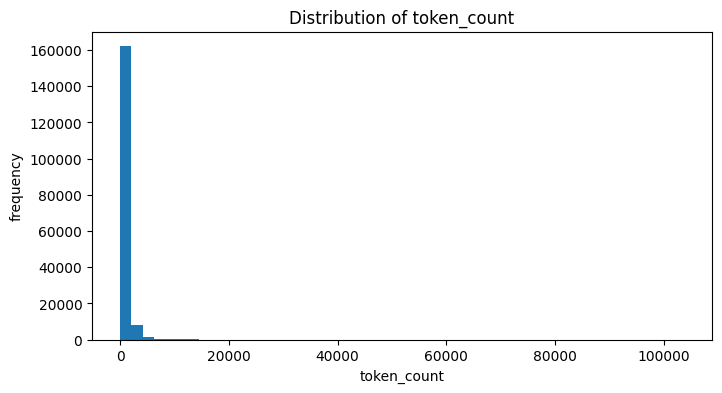

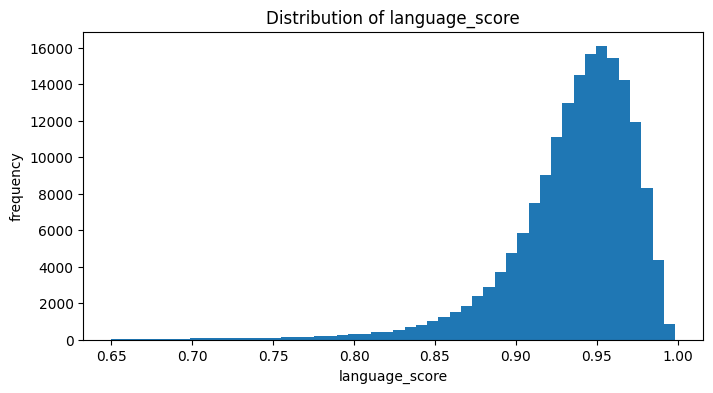

In [5]:
num_summary = full_df[["token_count", "language_score"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T
print("=== Numeric Summary ===")
display(num_summary)

fig = plt.figure(figsize=(8, 4))
plt.hist(full_df["token_count"].dropna(), bins=50)
plt.xlabel("token_count")
plt.ylabel("frequency")
plt.title("Distribution of token_count")
plt.show()

fig = plt.figure(figsize=(8, 4))
plt.hist(full_df["language_score"].dropna(), bins=50)
plt.xlabel("language_score")
plt.ylabel("frequency")
plt.title("Distribution of language_score")
plt.show()

## 4. Text Length and Information Density

In addition to `token_count`, this section derives extra features directly from `text`:

- character count
- word count
- average word length
- newline count
- an `almost_empty` flag

These features help identify records that may still be low-information despite not being extremely short.

In [6]:
def word_count(text):
    return len(re.findall(r"[A-Za-z]+", text)) if text else 0

def avg_word_len(text):
    words = re.findall(r"[A-Za-z]+", text) if text else []
    return sum(map(len, words)) / len(words) if words else 0

def newline_count(text):
    return text.count("\n") if isinstance(text, str) else 0

def almost_empty(text):
    core = re.sub(r"[^A-Za-z0-9]+", "", text) if text else ""
    return len(core) < 20

full_df["char_count"] = full_df["text_norm"].str.len()
full_df["word_count"] = full_df["text_norm"].apply(word_count)
full_df["avg_word_len"] = full_df["text_norm"].apply(avg_word_len)
full_df["newline_count"] = full_df["text"].apply(newline_count)
full_df["almost_empty"] = full_df["text_norm"].apply(almost_empty)

text_feature_summary = full_df[["char_count", "word_count", "avg_word_len", "newline_count"]].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T

print("=== Derived Text-Feature Summary ===")
display(text_feature_summary)

print("almost_empty ratio:", full_df["almost_empty"].mean())

corr_df = full_df[["token_count", "char_count", "word_count", "avg_word_len", "newline_count", "language_score"]].corr(numeric_only=True)
print("=== Correlation Matrix ===")
display(corr_df)

=== Derived Text-Feature Summary ===


,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
char_count,172447.0,3638.050143,5759.220982,136.000000,326.000000,480.00,1111.000000,2262.000000,4286.000000,7544.000000,10816.000000,23058.780000,481612.000000
word_count,172447.0,597.356782,960.610215,22.000000,55.000000,80.00,182.000000,371.000000,704.000000,1239.000000,1769.700000,3732.000000,79505.000000
avg_word_len,172447.0,4.905542,0.496169,2.865672,3.890029,4.14,4.557823,4.873843,5.225806,5.562895,5.768322,6.172776,8.964912
newline_count,172447.0,16.783435,28.854031,0.000000,0.000000,1.00,5.000000,10.000000,19.000000,37.000000,55.000000,112.000000,3172.000000


almost_empty ratio: 0.0
=== Correlation Matrix ===


,token_count,char_count,word_count,avg_word_len,newline_count,language_score
token_count,1.000000,0.991661,0.995073,-0.005993,0.751027,0.082974
char_count,0.991661,1.000000,0.994732,0.038893,0.744349,0.083993
word_count,0.995073,0.994732,1.000000,-0.011989,0.742322,0.102163
avg_word_len,-0.005993,0.038893,-0.011989,1.000000,0.038310,-0.331708
newline_count,0.751027,0.744349,0.742322,0.038310,1.000000,-0.015093
language_score,0.082974,0.083993,0.102163,-0.331708,-0.015093,1.000000


## 5. Language Profile

This section verifies:

- whether the shard is effectively English-only
- whether other language labels appear
- what low-`language_score` samples look like

In [7]:
lang_counts = full_df["language"].value_counts(dropna=False).to_frame("count")
lang_counts["ratio"] = lang_counts["count"] / len(full_df)

print("=== Language Distribution ===")
display(lang_counts)

low_lang_df = full_df[full_df["language_score"] < 0.90][
    ["language", "language_score", "token_count", "url", "text"]
].head(10)

print("=== Low-language_score Samples (Top 10) ===")
display(low_lang_df)

=== Language Distribution ===


,count,ratio
language,,
en,172447,1.0


=== Low-language_score Samples (Top 10) ===


,language,language_score,token_count,url,text
0,en,0.899284,203,https://www.townsquareapp.co/,"Welcome to Harrisonburg TownSquare.\nTownSquare brings together all your favorite local shops and makers in one cozy corner of the internet, so you can support your neighbors and find something tr..."
20,en,0.881102,1533,https://www.unitedstatesofganja.com/2025/01/22/exploring-the-thrill-of-online-pokies-in-australia-top-casinos-and-games/,Exploring the Thrill of Online Pokies in Australia Top Casinos and Games\nExperience the thrill of pokies online like never before! Whether you’re searching for real pokies or the best online casi...
24,en,0.887821,534,https://www.vancouverclub.ca/posts/hotel-rooms-reservation-guide-website,"The following online reservations are available through your member website: Club events, à la carte dining and hotel rooms.\nYour website also includes information for booking additional Club ser..."
26,en,0.887206,97,https://www.vetmeduni.ac.at/en/fundraising/your-donation-for-our-animal-hospital,"Your donation for our animal hospital\nYour donation goes directly to the treatment of the patient's animals, the high-quality clinic equipment (such as the most modern devices for tumor treatment..."
30,en,0.878465,189,https://www.vintagewinemerchants.com/products/2019-kathryn-kennedy-cabernet-sauvignon-estate,"93 Wine Enthusiast - The region's forest-like qualities show on the nose of this bottling, where hints of sandalwood, cigar box, oregano and thyme add to the dried red-fruit aromas. The palate off..."
33,en,0.896914,373,https://www.visitarizona.com/events/lake-powell-sxs-extravaganza/,Lake Powell SXS Extravaganza\nOct 10th – Oct 12th\n- Time4:00 PM to 5:00 PM\nWelcome to the Lake Powell SXS Extravaganza!\nGet ready for a heart-pounding adventure set against the stunning backdro...
35,en,0.870176,249,https://www.vitarsis.com/?v=5c2a35ef64b8,"Unlock Your Inner Potential\nReady for meaningful change? Vitarsis equips you with unique tools and focused approaches to help you elevate your mindset, enhance your focus, and build the life you ..."
36,en,0.834038,114,https://www.voltpiint.shop/products/blue-sneakers-for-men,"The LOUIS STITCH PLAY Sneakers take their inspiration from the dynamic rhythm of playful urban life. Heartcrafted with utmost perfection, these sneakers feature comfortable yet stylish and modern ..."
38,en,0.892725,129,https://www.vtmarkets.com/notification/v2023030801/,"Notification of Server Upgrade – Jun 12 ,2025\nDear Client, As part of our commitment to provide the most reliable service to our clients, there will be maintenance …\nThe adjustment of DST will b..."
55,en,0.866001,268,https://www.willerby.com/parks/south-west/somerset/weston-super-mare,"Steeped with Victorian history and dominated by a glorious beach\nFind out more about this Victorian splendour at the Weston Museum, or explore 40 acres of rolling Somerset countryside Puxton Park..."


## 6. Source Domains and URL Patterns

This section examines:

- which domains appear most often
- how concentrated or dispersed the sources are
- whether URLs contain common weak-content patterns such as tag, category, author, or pagination pages

In [8]:
def get_domain(url):
    try:
        return urlparse(str(url)).netloc.lower()
    except:
        return ""

full_df["domain"] = full_df["url"].apply(get_domain)

domain_counts = full_df["domain"].value_counts().to_frame("count")
domain_counts["ratio"] = domain_counts["count"] / len(full_df)

print("=== Top 20 Domains ===")
display(domain_counts.head(20))

url_pattern_flags = pd.DataFrame({
    "contains_tag": full_df["url"].fillna("").astype(str).str.contains(r"/tag/", case=False, regex=True),
    "contains_tags": full_df["url"].fillna("").astype(str).str.contains(r"/tags/", case=False, regex=True),
    "contains_category": full_df["url"].fillna("").astype(str).str.contains(r"/category/", case=False, regex=True),
    "contains_author": full_df["url"].fillna("").astype(str).str.contains(r"/author/", case=False, regex=True),
    "contains_page_num": full_df["url"].fillna("").astype(str).str.contains(r"/page/\d+", case=False, regex=True),
    "contains_replytocom": full_df["url"].fillna("").astype(str).str.contains(r"replytocom=", case=False, regex=True),
})

url_pattern_summary = pd.DataFrame({
    "count": url_pattern_flags.sum(),
    "ratio": url_pattern_flags.mean()
}).sort_values("count", ascending=False)

print("=== Weak-Content URL Pattern Summary ===")
display(url_pattern_summary)

=== Top 20 Domains ===


,count,ratio
domain,,
pubmed.ncbi.nlm.nih.gov,59,0.000342
plandisney.disney.go.com,53,0.000307
www.telegraph.co.uk,46,0.000267
www.ibtimes.co.uk,43,0.000249
www.cbsnews.com,42,0.000244
www.latimes.com,38,0.000220
www.sciencedaily.com,38,0.000220
www.prweb.com,38,0.000220
timesofindia.indiatimes.com,37,0.000215


=== Weak-Content URL Pattern Summary ===


,count,ratio
contains_tag,1788,0.010368
contains_category,862,0.004999
contains_page_num,684,0.003966
contains_author,297,0.001722
contains_tags,223,0.001293
contains_replytocom,5,0.000029


## 7. Time Distribution

This section converts `date` into parsed timestamps and checks:

- date validity
- the distribution of crawl dates
- the distribution of crawl hours

=== Date Parsing Quality ===


,metric,value
0,invalid_date_ratio,0.0
1,valid_date_ratio,1.0


=== Distribution by Date ===


,count
date_parsed,
2025-06-16,12731
2025-06-17,14394
2025-06-18,13574
2025-06-19,13605
2025-06-20,14506
2025-06-21,13915
2025-06-22,13479
2025-06-23,13369
2025-06-24,13893


=== Distribution by Hour ===


,count
date_parsed,
0,7216
1,8315
2,7485
3,6871
4,8519
5,7722
6,6602
7,8246
8,7835


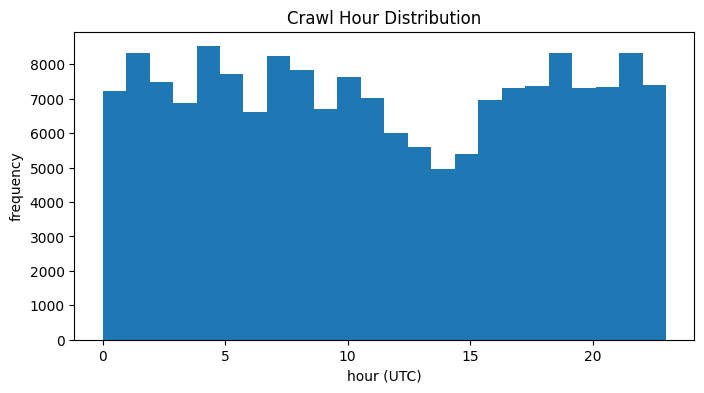

In [9]:
full_df["date_parsed"] = pd.to_datetime(full_df["date"], errors="coerce", utc=True)

date_quality = pd.DataFrame({
    "metric": ["invalid_date_ratio", "valid_date_ratio"],
    "value": [full_df["date_parsed"].isna().mean(), full_df["date_parsed"].notna().mean()]
})

print("=== Date Parsing Quality ===")
display(date_quality)

valid_dates = full_df["date_parsed"].dropna()

if len(valid_dates) > 0:
    day_counts = valid_dates.dt.date.value_counts().sort_index().to_frame("count")
    hour_counts = valid_dates.dt.hour.value_counts().sort_index().to_frame("count")

    print("=== Distribution by Date ===")
    display(day_counts.tail(10))

    print("=== Distribution by Hour ===")
    display(hour_counts)

    fig = plt.figure(figsize=(8, 4))
    plt.hist(valid_dates.dt.hour, bins=24)
    plt.xlabel("hour (UTC)")
    plt.ylabel("frequency")
    plt.title("Crawl Hour Distribution")
    plt.show()
else:
    print("No valid parsed dates.")

## 8. Outliers and Manual Inspection

Aggregate statistics are not enough on their own. This section surfaces:

- the shortest texts
- the longest texts
- the lowest-`language_score` texts
- a random sample of records

These views make it easier to inspect thin pages, unusually long documents, and noisy examples directly.

In [10]:
cols_for_review = ["token_count", "language_score", "url", "domain", "text"]

print("=== Shortest Texts (Top 10 by token_count) ===")
display(full_df.sort_values("token_count", ascending=True)[cols_for_review].head(10))

print("=== Longest Texts (Top 10 by token_count) ===")
display(full_df.sort_values("token_count", ascending=False)[cols_for_review].head(10))

print("=== Lowest language_score Records (Top 10) ===")
display(full_df.sort_values("language_score", ascending=True)[cols_for_review].head(10))

print("=== Random Sample of 10 Records ===")
display(full_df.sample(10, random_state=RANDOM_SEED)[cols_for_review])

=== Shortest Texts (Top 10 by token_count) ===


,token_count,language_score,url,domain,text
9522,31,0.856314,https://gdg.community.dev/forum/how-to-get-into-top-us-universities-online-11717/,gdg.community.dev,Skip to main content\nRoad to Google Developers Certification\nHow to get into top US universities? [Online]\nThere are no topics in this forum.
66549,34,0.822446,https://www.brunswickpha.org/waitlist,www.brunswickpha.org,Skip to Main Content\nA Message from the Executive Director\nBoard of Commissioners\nThe Waiting List for Section 8 is closed at this time.\nRead our cookie use policy
138234,35,0.767501,https://www.picksbar.com/media,www.picksbar.com,top of page\nfood & drink\nUse tab to navigate through the menu items.\nUpload supported file (Max 15MB)\ndate interested in:\nbottom of page
62722,35,0.874195,https://www.beyondmeat.com/en-US/recipes/lindsey-vonns-beyond-beef-chili,www.beyondmeat.com,"Lindsey Vonn's Vegan Chili Recipe\nThis Recipe Features\nNew Beyond Beef\nJOIN THE MOVEMENT\nTo receive exclusive Beyond Meat® offers, updates and more."
135970,36,0.657335,https://www.btwchurch.com/product-page/unisex-grow-through-what-you-go-through-tee,www.btwchurch.com,top of page\nHome & Living\nUse tab to navigate through the menu items.\nUnisex Grow Through What You Go Through Tee\nAdd to Cart\nbottom of page
170073,37,0.894119,https://www.coventry.ac.uk/nite/events/?eventType=1954,www.coventry.ac.uk,"International teacher training\nInformation for schools\nWork with us\nUse the filters below to refine your search...\nIf you can't find what you're looking for, view all events."
146797,37,0.721844,https://www.gemrain.net/download-outlines/sa-efla-1%3A-excel-focus-learning-advanced,www.gemrain.net,top of page\nUse tab to navigate through the menu items.\nSA-EFLA-1: Excel Focus Learning Advanced\nDownload Course Outline for:\nbottom of page
22986,38,0.727914,https://www.etsco.org/,www.etsco.org,top of page\nNon signalized pedestrian crossing\nTraffic Safety Culture\nUse tab to navigate through the menu items.\nMORE INFORMATION >>\nEuropean Traffic Safety Culture Observatory\nbottom of page
124674,39,0.915230,https://sascpa.org/m/create-account,sascpa.org,"Signed in as:\nBy creating an account, you may receive newsletters or promotions.\nAlready have an account? Sign in\nCopyright © 2025 SAS CPA LLC - All Rights Reserved."
118697,39,0.875836,https://calle.robcon.se/2016/09/23/simple-web-server/index.html,calle.robcon.se,This can be done very easily.\nThe python way:\nThe PHP way:\nBoth serves file in the current directory. The example port 8000\ncan be change to suit your needs.


=== Longest Texts (Top 10 by token_count) ===


,token_count,language_score,url,domain,text
32060,103654,0.989143,https://www.gutenberg.net.au/ebooks01/0100151h.html,www.gutenberg.net.au,"Australia a treasure-trove of literature treasure found hidden with no evidence of ownership |\nBROWSE the site for other works by this author (and our other authors) or get HELP Reading, Download..."
84229,102837,0.935425,https://sms201995.com/2024/09/,sms201995.com,The pilot test (n=16) reported large amounts of comfort and acceptability toward using mHealth programs when you look at the clinical environment but experienced numerous infrastructure difficulti...
102144,97726,0.977453,https://goingtojesus.com/suffering-and-the-saints.html,goingtojesus.com,"and the Saints\nLet those who suffer according to the will of God\ncommit their souls to Him in well doing, as unto a faithful Creator.\nJohn David Clark, Sr.\nTo my father, George C. Clark, Sr.,\..."
90001,87569,0.836262,https://whitby-taxis.co.uk/category/business/,whitby-taxis.co.uk,"Solo Travel Fear #1: What about eating in a restaurant alone? Bring a book, newspaper, magazine, crossword puzzle. and savor! It is not really a strange or unusual thing to eat alone, in fact peop..."
70135,78499,0.966035,https://www.anandgholap.net/Nirvana-GSA.htm,www.anandgholap.net,Theosophy Home Our Facebook Group |\nA Study in Synthetic Consciousness\nTwo Elder Brothers\nAnnie Besant and Charles Webster Leadbeater by whose aid these experiences were possible and to those i...
45136,68144,0.959962,https://www.ola.org/en/legislative-business/committees/interior/parliament-43/transcripts/committee-transcript-2022-nov-14,www.ola.org,ON THE INTERIOR\nDES AFFAIRES INTÉRIEURES\nMonday 14 November 2022 Lundi 14 novembre 2022\nThe committee met at 0900 in committee room 1.\nMinistry of Energy\nThe Chair (Mr. Aris Babikian): The St...
12141,66996,0.983838,https://www.gutenberg.org/files/20341/20341-h/20341-h.htm,www.gutenberg.org,"The Project Gutenberg EBook of Grace Harlowe's Overland Riders in the Great North Woods, by Jessie Graham Flower This eBook is for the use of anyone anywhere at no cost and with almost no restrict..."
905,62381,0.947122,https://pdfcoffee.com/2pac-vs-biggie-an-illustrated-history-of-rapx27s-greatest-battle-2-pdf-free.html,pdfcoffee.com,"CONTENTS Preface Chapter 1 PORTRAITS OF THE ARTISTS AS YOUNG MEN Chapter 2 WHERE THEY CAME FROM, WHERE THEY WENT Chapter\nViews 647 Downloads 25 File size 19MB\nA N I LLU STRATED - HISTORY OF - BR..."
51043,59636,0.979010,http://www.adjudication.co.uk/archive/iframe/case/809,www.adjudication.co.uk,Case Number: HT 02 354\nNeutral Citation Number: EWHC 3124 (TCC)\nIN THE HIGH COURT OF JUSTICE\nQUEEN’S BENCH DIVISION\nTECHNOLOGY AND CONSTRUCTION COURT\n17 December 2003\nHis Honour Judge Humph...
68602,55957,0.964299,https://www.globalgreyebooks.com/online-ebooks/franz-cumont_astrology-and-religion-among-the-greeks-and-romans_complete-text.html,www.globalgreyebooks.com,First published in 1912.\nThis online edition was created and published by Global Grey on the 7th March 2023.\nIt is the purpose of these lectures delivered under the auspices of the American Comm...


=== Lowest language_score Records (Top 10) ===


,token_count,language_score,url,domain,text
2404,358,0.650054,https://fi.abtk.hu/hu/hps-seminar-series/503-roland-poellinger2,fi.abtk.hu,"A Tudománytörténet és Tudományfilozófia Kutatócsoport szeretettel meghív minden érdeklődőt Roland Poellinger (Munich Center for Mathematical Philosophy, LMU Munich) május 5-én délután 16 órától ta..."
8415,162,0.650239,https://www.apponic.com/s/icon-package/mac/,www.apponic.com,Home & Education\nNetwork & Internet\nPreviously known as Icon Creator. The fastest icon conversion tool.\nResize your icon image to all common sizes.\nEasily create Apple icon images for apps.\nt...
2976,228,0.650288,https://thepulsemag.com/2008/11/2008-turkey-crawl,thepulsemag.com,"The folks behind the newly formed Canal District Business Association are hosting the 1st Annual Turkey Crawl. The event, which combines donating a turkey or cash to the Worcester County Food Bank..."
37919,1144,0.650552,http://powysstud.com/crafting-superior-circular-knives-through-grinder-services/,powysstud.com,Crafting Superior Circular Knives Through Grinder Services\nSurfacе grindеr sеrvicеs arе еssеntial in thе fiеld of prеcision machining for shaping and rеfining diffеrеnt matеrials to match prеcisе...
122172,606,0.651055,https://addons.opera.com/ko/extensions/?tag=sidebar&page=2&order=popular,addons.opera.com,"Give easy access to ChessGrow from sidebar.\nGoogle Messages for Opera Sidebar\nThis Add-On allows you to send text messages from your Opera Browser, to anyone you want.\nManage your tabs in the s..."
105402,275,0.651157,https://bookmarkstime.com/story20165663/realize-your-dream-home-with-a-private-mortgage-loan,bookmarkstime.com,Realize Your Dream Home with a Private Mortgage Loan\n30 days ago\nAre you searching for the perfect home but facing challenges with traditional mortgage options? A private mortgage loan could be ...
158448,52,0.651382,https://calm.abdn.ac.uk/archives/Record.aspx?src=CalmView.Catalog&id=MS+3004%2FV75,calm.abdn.ac.uk,"MS 3004 - Fraser of Philorth papers\nGB 0231 University of Aberdeen, Special Collections\nDrainage system plans\nPlans of drainage system for low ground at Philorth, incorporating pumping station...."
15017,729,0.651395,https://maps.network/Mary-PolitesAA-MArch-BArch-AA,maps.network,"Mary Polites 玛丽 普莱蒂斯\nMary Polites holds a master´s degree in architecture from the Emergent Technologies program at the London Architectural Association, and is co-director of the Biomimetic Desi..."
56804,389,0.651489,https://econpapers.repec.org/paper/haljournl/hal-04674582.htm?ref,econpapers.repec.org,LA SOUVERAINETÉ: LE REMPART DE L'AVANTAGE COMPARATIF DES NATIONS DANS UN MARCHÉ NUMÉRIQUE\nFrancesco Bonfiglio and\nFrancisco Condis Y Troyano ()\nAdditional contact information\nFrancesco Bonfigl...
48756,96,0.651513,https://www.lebij.be/toolbox/youth-exchange-group-leader-go-yegling/,www.lebij.be,"Education and Culture DG Youth in Action Programme\nTravail de jeunesse, Inclusion\nCollective and synergetic effort of more that 20 people coming from all the corner of the European continent. It..."


=== Random Sample of 10 Records ===


,token_count,language_score,url,domain,text
88554,371,0.959616,https://www.marketplace.org/story/2012/04/05/michigan-and-detroit-agree-deal-help-citys-deficit,www.marketplace.org,"Michigan and Detroit agree on deal to help city’s deficit\nThe city of Detroit has a projected a deficit of more than $200 million his year — and it could run out of money by June. Last night, Det..."
93333,76,0.743098,https://kiddyland.pk/products/barbie-mirror-for-girls,kiddyland.pk,Hello Kitty Dressing Set For Girls\nLength 27 Inches\nWidth 36 Inches\nDepth 16 Inches\nMaterial wooden laminated sheet\nIt can easily be clean with wet duster.\nScratch-resistant finish protects ...
154498,237,0.944833,https://www.va.gov/outreach-and-events/events/77198/,www.va.gov,"Navigating the Journey from Caregiver to Survivor - Online\nJoin Dr. Qwynn Galloway-Salazar for a heartfelt discussion of finding strength, healing and connection in the caregiver to survivor jour..."
60880,279,0.933934,https://www.alfozan.com/press-releases/tkhryj-awl-dft-mn-brnamj-majstyr-adart-almwssat-ghyr-alrbhyt-mnpm,www.alfozan.com,"Graduation of the First Cohort of the Master of Nonprofit Management Program (MNPM)\nAl Khobar, May 2025\nAl Fozan Academy for the Development of Nonprofit Leadership celebrated the graduation of ..."
35722,1083,0.967340,https://www.hyattbuyutat-riyadh.website/top-attractions-nearby.html,www.hyattbuyutat-riyadh.website,"Looking for top attractions in Riyadh around the Hyatt Buyutat Apartment, but not sure where to start? From Faisaliyah Tower to Red Sand Dunes that make this property preferred choice for guest vi..."
109646,217,0.936304,https://mobilebodysculptmiami.com/our-services/tec-body-shape/,mobilebodysculptmiami.com,"Liquefy fat and drain it away through our heated, pulsed ultrasound.\nTargeted muscle contraction leads to a reduction in fat thickness.\nThe TEC Body Shape device produces an electromagnetic fiel..."
49082,604,0.950338,https://www.westlondonliving.co.uk/food-drink/bars-pubs/meraki-bar/,www.westlondonliving.co.uk,"Owned by the team behind Zuma and Roka, and hidden underneath the restaurant of the same name, Meraki Bar serves cocktails and sharing mezze dishes in lavish surroundings.\nWe were sat in the main..."
155135,83,0.920289,https://just-watch.club/watch/episode/1745927/this-is-no-ordinary-lawsuit-off-track-cracking-the-code,just-watch.club,"Enter your email address and we'll send you a link to reset your password.\nThe climate change lawsuit that could stop the U.S. government from supporting fossil fuels; and, how America’s railroad..."
127960,627,0.943340,https://livecasino.monster/what-is-the-best-bet-in-roulette/,livecasino.monster,"Roulette is a popular casino game often depicted in films as glamorous, exciting, and incredibly lucrative. These depictions are not far from reality as knowing the best roulette bets can minimize..."
115780,554,0.940794,https://usa.prefijotelefono.com/cities/kirkland-wa/,usa.prefijotelefono.com,"Kirkland, Washington, located on the eastern shore of Lake Washington, is part of King County and is approximately 20 miles east of Seattle. Incorporated in 1905, the city has a rich history roote..."


## 9. Summary Audit

This section summarizes the main observed properties of the shard in one compact table.

In [11]:
audit = {}

audit["row_count"] = len(full_df)
audit["column_count"] = full_df.shape[1]
audit["null_columns_gt_0"] = int((full_df.isna().mean() > 0).sum())
audit["duplicate_url_ratio"] = float(full_df["url"].duplicated().mean())
audit["duplicate_text_exact_ratio"] = float(full_df["text_norm"].duplicated().mean())
audit["english_ratio"] = float((full_df["language"].fillna("").str.lower() == "en").mean())
audit["low_language_score_ratio_lt_0_9"] = float((full_df["language_score"] < 0.9).mean())
audit["short_text_ratio_lt_100_tokens"] = float((full_df["token_count"] < 100).mean())
audit["almost_empty_ratio"] = float(full_df["almost_empty"].mean())
audit["unique_domain_count"] = int(full_df["domain"].nunique())
audit["top_domain_share"] = float(full_df["domain"].value_counts(normalize=True).iloc[0])

audit_df = pd.DataFrame({"metric": list(audit.keys()), "value": list(audit.values())})
display(audit_df)

,metric,value
0,row_count,172447.000000
1,column_count,17.000000
2,null_columns_gt_0,0.000000
3,duplicate_url_ratio,0.000087
4,duplicate_text_exact_ratio,0.000000
5,english_ratio,1.000000
6,low_language_score_ratio_lt_0_9,0.139452
7,short_text_ratio_lt_100_tokens,0.039392
8,almost_empty_ratio,0.000000
9,unique_domain_count,139653.000000
